# Part 3: Sales Data Analysis and Predictive Modeling

This notebook applies a full data science workflow to the sales dataset, including data cleaning, exploratory analysis, statistical testing, market basket analysis, and machine learning for revenue prediction.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-whitegrid')

# Load dataset from a robust set of possible locations
candidates = [
    Path('Sales Data.csv'),
    Path('Part3/Sales Data.csv'),
    Path.cwd() / 'Sales Data.csv',
    Path.cwd() / 'Part3' / 'Sales Data.csv',
]

for candidate in candidates:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError('Could not find Sales Data.csv in the expected locations.')

df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
print(df.head())
print('\nColumns:', list(df.columns))
print('\nMissing values:\n', df.isnull().sum())

Dataset shape: (185950, 11)
   Unnamed: 0  Order ID               Product  Quantity Ordered  Price Each  \
0           0    295665    Macbook Pro Laptop                 1     1700.00   
1           1    295666    LG Washing Machine                 1      600.00   
2           2    295667  USB-C Charging Cable                 1       11.95   
3           3    295668      27in FHD Monitor                 1      149.99   
4           4    295669  USB-C Charging Cable                 1       11.95   

            Order Date                        Purchase Address  Month  \
0  2019-12-30 00:01:00  136 Church St, New York City, NY 10001     12   
1  2019-12-29 07:03:00     562 2nd St, New York City, NY 10001     12   
2  2019-12-12 18:21:00    277 Main St, New York City, NY 10001     12   
3  2019-12-22 15:13:00     410 6th St, San Francisco, CA 94016     12   
4  2019-12-18 12:38:00           43 Hill St, Atlanta, GA 30301     12   

     Sales            City  Hour  
0  1700.00   New York C

## 1. Data Understanding and Preprocessing

This section loads the dataset, checks its structure, and prepares it for analysis by converting date and text-based fields into useful features.

In [15]:
# Convert date column and engineer useful features
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month_name()
df['Hour'] = df['Order Date'].dt.hour
df['Day'] = df['Order Date'].dt.day_name()

# Create a revenue column
# Sales column is already available, but this is derived from quantity and unit price
if 'Sales' not in df.columns:
    df['Sales'] = df['Quantity Ordered'] * df['Price Each']

# Clean text fields
for col in ['Product', 'City', 'Month', 'Day']:
    df[col] = df[col].astype(str).str.strip()

# Basic preprocessing for modeling
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
df['Product_Code'] = le_product.fit_transform(df['Product'])

le_city = LabelEncoder()
df['City_Code'] = le_city.fit_transform(df['City'])

# Drop redundant or non-numeric identifier-like columns
model_df = df.drop(columns=['Order ID', 'Purchase Address', 'Product', 'City', 'Order Date', 'Day'], errors='ignore')

print(model_df.dtypes)
print('\nPrepared data sample:')
print(model_df.head())

Unnamed: 0            int64
Quantity Ordered      int64
Price Each          float64
Month                object
Sales               float64
Hour                  int64
Product_Code          int32
City_Code             int32
dtype: object

Prepared data sample:
   Unnamed: 0  Quantity Ordered  Price Each     Month    Sales  Hour  \
0           0                 1     1700.00  December  1700.00     0   
1           1                 1      600.00  December   600.00     7   
2           2                 1       11.95  December    11.95    18   
3           3                 1      149.99  December   149.99    15   
4           4                 1       11.95  December    11.95    12   

   Product_Code  City_Code  
0            13          5  
1            11          5  
2            15          5  
3             2          7  
4            15          0  


## 2. Exploratory Data Analysis

This section explores monthly revenue, city contributions, product popularity, and ordering patterns to answer the research questions.

Top months by revenue:
 Month
December     4613443.34
October      3736726.88
April        3390670.24
November     3199603.20
May          3152606.75
March        2807100.38
July         2647775.76
June         2577802.26
August       2244467.88
February     2202022.42
September    2097560.13
January      1822256.73
Name: Sales, dtype: float64


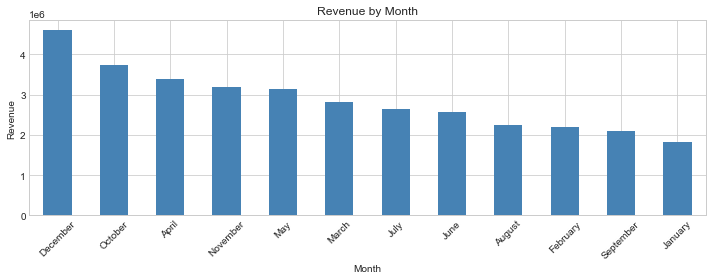


Top cities by sales:
 City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Sales, dtype: float64


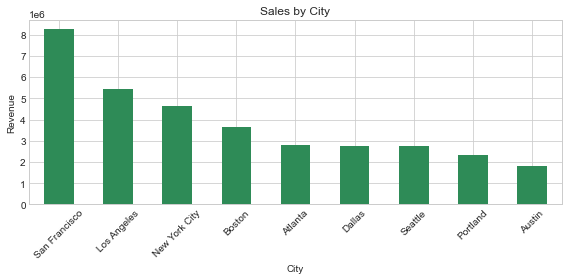


Top products by quantity sold:
 Product
AAA Batteries (4-pack)      31017
AA Batteries (4-pack)       27635
USB-C Charging Cable        23975
Lightning Charging Cable    23217
Wired Headphones            20557
Name: Quantity Ordered, dtype: int64

Top products by revenue:
 Product
Macbook Pro Laptop        8037600.00
iPhone                    4794300.00
ThinkPad Laptop           4129958.70
Google Phone              3319200.00
27in 4K Gaming Monitor    2435097.56
Name: Sales, dtype: float64


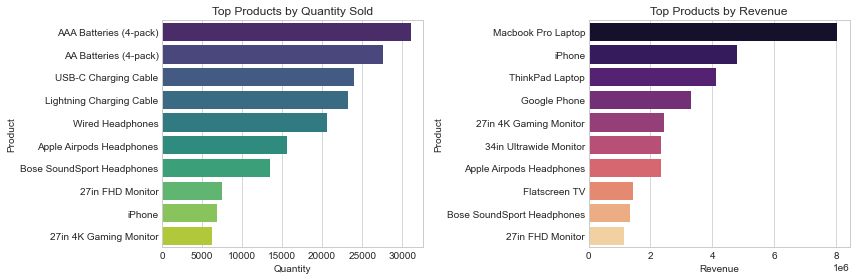


Order activity by hour:
 0    3910
1    2350
2    1243
3     831
4     854
5    1321
6    2482
7    4011
8    6256
9    8748
Name: Hour, dtype: int64


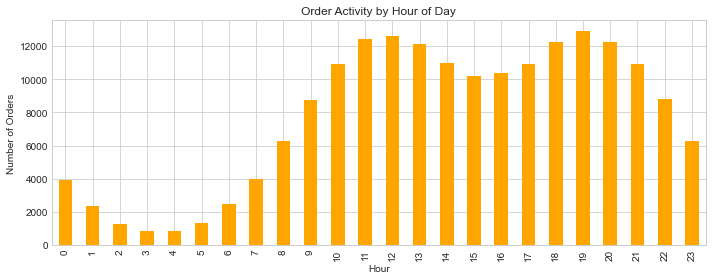

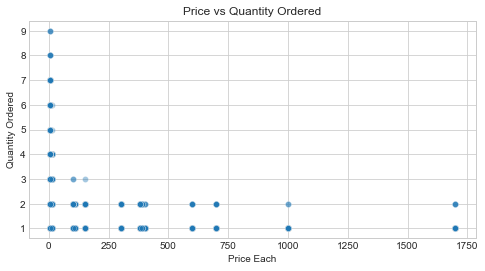

In [16]:
# Monthly revenue
monthly_revenue = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print('Top months by revenue:\n', monthly_revenue)

plt.figure(figsize=(10, 4))
monthly_revenue.plot(kind='bar', color='steelblue')
plt.title('Revenue by Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# City contribution
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
print('\nTop cities by sales:\n', city_sales)

plt.figure(figsize=(8, 4))
city_sales.head(10).plot(kind='bar', color='seagreen')
plt.title('Sales by City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top products by quantity and revenue
product_qty = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)
product_revenue = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

print('\nTop products by quantity sold:\n', product_qty.head())
print('\nTop products by revenue:\n', product_revenue.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=product_qty.head(10).values, y=product_qty.head(10).index, ax=axes[0], palette='viridis')
axes[0].set_title('Top Products by Quantity Sold')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Product')

sns.barplot(x=product_revenue.head(10).values, y=product_revenue.head(10).index, ax=axes[1], palette='magma')
axes[1].set_title('Top Products by Revenue')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('Product')
plt.tight_layout()
plt.show()

# Order activity by hour
hour_counts = df['Hour'].value_counts().sort_index()
print('\nOrder activity by hour:\n', hour_counts.head(10))

plt.figure(figsize=(10, 4))
hour_counts.plot(kind='bar', color='orange')
plt.title('Order Activity by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# Price vs frequency
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Price Each', y='Quantity Ordered', alpha=0.4)
plt.title('Price vs Quantity Ordered')
plt.xlabel('Price Each')
plt.ylabel('Quantity Ordered')
plt.show()


## 3. Statistical Analysis

This section uses simple statistical techniques to examine the relationships between price, quantity, and revenue.

In [25]:
from scipy import stats

# Correlation between price and quantity
corr_price_qty = df['Price Each'].corr(df['Quantity Ordered'])
print('Correlation between Price Each and Quantity Ordered:', corr_price_qty)

# Test whether revenue differs across months
monthly_mean_sales = df.groupby('Month')['Sales'].mean()
print('\nAverage sales by month:\n', monthly_mean_sales)

# One-way ANOVA for sales across months
anova = stats.f_oneway(*[group['Sales'] for _, group in df.groupby('Month')])
print('\nANOVA p-value for sales across months:', anova.pvalue)

# Price-based grouping
high_price = df[df['Price Each'] >= df['Price Each'].median()]
low_price = df[df['Price Each'] < df['Price Each'].median()]
print('\nMedian price:', df['Price Each'].median())
print('Average quantity for high-price items:', high_price['Quantity Ordered'].mean())
print('Average quantity for low-price items:', low_price['Quantity Ordered'].mean())


Correlation between Price Each and Quantity Ordered: -0.14827234034551456

Average sales by month:
 Month
April        185.495390
August       187.648849
December     184.655913
February     183.884962
January      187.687376
July         185.249826
June         190.187565
March        185.250471
May          190.305852
November     182.074956
October      184.238580
September    180.497387
Name: Sales, dtype: float64

ANOVA p-value for sales across months: 0.3422067659779472

Median price: 14.95
Average quantity for high-price items: 1.0187403195859428
Average quantity for low-price items: 1.2582954282160408


## 4. Association Rule / Market Basket Analysis

This section identifies products that are frequently purchased together.

In [22]:
import sys
!{sys.executable} -m pip install mlxtend -q

from mlxtend.frequent_patterns import apriori, association_rules

# Build a boolean basket matrix so mlxtend works correctly
basket = (
    df.groupby(['Order ID', 'Product'])['Quantity Ordered']
      .sum()
      .unstack(fill_value=0)
      .gt(0)
      .astype(bool)
)

# Use lower thresholds for this dataset to generate meaningful rules
frequent_itemsets = apriori(basket, min_support=0.005, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.2)

if rules.empty:
    frequent_itemsets = apriori(basket, min_support=0.002, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)

print('Frequent itemsets:')
print(frequent_itemsets.head())
print('\nAssociation rules:')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

Frequent itemsets:
    support                  itemsets
0  0.022966            (20in Monitor)
1  0.034886  (27in 4K Gaming Monitor)
2  0.042020        (27in FHD Monitor)
3  0.034600  (34in Ultrawide Monitor)
4  0.115122   (AA Batteries (4-pack))

Association rules:
         antecedents                 consequents   support  confidence  \
0     (Google Phone)      (USB-C Charging Cable)  0.005587    0.180551   
1           (iPhone)  (Lightning Charging Cable)  0.005666    0.147807   
2  (Vareebadd Phone)      (USB-C Charging Cable)  0.002062    0.178208   

       lift  
0  1.474120  
1  1.220804  
2  1.454996  


## 5. Machine Learning for Revenue Prediction

A regression model is trained to predict sales revenue using engineered features such as month, city, hour, and product category.

In [24]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant

# Create a simple regression-style workflow with safe column names
model_df2 = model_df[['Quantity Ordered', 'Price Each', 'Hour', 'Sales']].copy()
model_df2 = model_df2.rename(columns={'Price Each': 'Price_Each'})
model_df2['Revenue_per_Unit'] = model_df2['Sales'] / model_df2['Quantity Ordered'].replace(0, np.nan)
model_df2 = model_df2.dropna()

X = add_constant(model_df2[['Quantity Ordered', 'Price_Each', 'Hour']])
y = model_df2['Sales']

regression_model = OLS(y, X).fit()
print(regression_model.summary())

pred = regression_model.predict(X)
mae = np.mean(np.abs(y - pred))
mse = np.mean((y - pred) ** 2)
r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print('MAE:', round(mae, 2))
print('MSE:', round(mse, 2))
print('R2:', round(r2, 2))

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 4.084e+07
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:09:37   Log-Likelihood:            -7.4024e+05
No. Observations:              185950   AIC:                         1.480e+06
Df Residuals:                  185946   BIC:                         1.481e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -6.6324      0.118  